#Fase 4 y 5 — Deep Learning + Evaluation (CRISP-DM)
#Sistema Inteligente de Recomendación de Películas — MovieLens 25M

Notebook `04_DeepLearning_Embeddings.ipynb` — **CRISP-DM Fase 4 (Modeling)** + **CRISP-DM Fase 5 (Evaluation)**.

Continuamos desde la Fase 4 clásica (`03_ML_Baseline_AutoML.ipynb`) que dejó establecido el límite del Machine Learning tabular:
* **SVD (Matrix Factorization)** como el campeón clásico con un RMSE de **0.8140**.
* Clústeres de usuarios y películas extraídos y persistidos.

Este notebook cubre la transición hacia arquitecturas no lineales:
* **Modeling (Fase 4):** Diseño, construcción y entrenamiento de una red Neural Collaborative Filtering (NCF) con PyTorch.
* **Evaluation (Fase 5):** Análisis de curvas de aprendizaje, diagnóstico de sobreajuste y comparativa directa contra el modelo clásico.

### Entregables de este notebook (especificaciones del proyecto)

| # | Entregable | Implementación en este notebook |
| :--- | :--- | :--- |
| 1 | **Diseño e implementación del modelo** profundo. | Sección 3 — **Arquitectura NCF** (Neural Collaborative Filtering) de Dos Torres. |
| 2 | **Embeddings o representación latente** explícita. | Sección 3 — Capas `nn.Embedding` de 64 dimensiones para usuarios y películas. |
| 3 | **Entrenamiento y evaluación**. | Sección 4 — Bucle de 10 épocas con registro estricto de MSELoss y RMSE. |
| 4 | **Curvas de entrenamiento** y explicación de sobreajuste. | Sección 5 — Visualización de curvas de aprendizaje y diagnóstico de **Overfitting**. |
| 5 | **Comparación con baseline clásico**. | Sección 6 — Gráfico comparativo y tabla de RMSE (NCF vs SVD). |

### Decisiones metodológicas clave

1. **Biblioteca:** `PyTorch` — estándar en la industria para arquitecturas profundas, permite control total sobre los grafos y los embeddings latentes.
2. **Dataset:** Muestra temporal del **5%** — clonada directamente desde GitHub para garantizar la ejecución en hardware local y evidenciar empíricamente la dependencia de datos del Deep Learning (Data Starvation).
3. **Función de pérdida:** `MSELoss` — al predecir un rating continuo (0.5 a 5.0), el error cuadrático medio es la métrica matemáticamente correcta para penalizar errores severos.
4. **Regularización:** `Dropout (0.2)` y `Weight Decay (L2)` — incorporados en la arquitectura para mitigar la rápida memorización de la red neuronal.

In [7]:
# ==========================================
# 1. IMPORTACIONES Y ENTORNO
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Reproducibilidad estricta
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento configurado: {device}")


Dispositivo de entrenamiento configurado: cpu


### 1. Preparación de Datos (PyTorch DataLoaders)
Cargaremos el subconjunto de datos procesado en la Fase 2 (formato Parquet). En PyTorch, necesitamos mapear los IDs de usuarios y películas a índices continuos que comiencen desde cero, para que puedan ser leídos correctamente por las capas `nn.Embedding`.

In [8]:
# ==========================================
# 2. CARGA DE DATOS DESDE GITHUB (Muestra 5%)
# ==========================================
repo_url = "https://github.com/Coded7Chaos/OmniRec-Movies.git"
repo_name = "OmniRec-Movies"

# Clonar el repositorio si no existe
if not os.path.exists(repo_name):
    print("Clonando el repositorio desde GitHub...")
    !git clone {repo_url}
else:
    print("El repositorio ya está clonado en este entorno.")

# Movernos a la carpeta del proyecto
if os.getcwd().split('/')[-1] != repo_name:
    os.chdir(repo_name)

# Usamos la muestra del 5% temporalmente para poder avanzar
ruta_parquet = 'data/intermediate/ratings_sample_5pct.parquet'

try:
    ratings = pd.read_parquet(ruta_parquet)
    print(f"¡Datos cargados exitosamente! Shape de la matriz: {ratings.shape}")
except FileNotFoundError:
    print(f"❌ ERROR: No se encontró el archivo en: {ruta_parquet}")
    raise

# 2.1 Mapeo de IDs a índices continuos para PyTorch
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user2idx = {o: i for i, o in enumerate(user_ids)}
movie2idx = {o: i for i, o in enumerate(movie_ids)}

ratings['user_idx'] = ratings['userId'].map(user2idx)
ratings['movie_idx'] = ratings['movieId'].map(movie2idx)

num_users = len(user_ids)
num_movies = len(movie_ids)
print(f"Total Usuarios únicos: {num_users} | Total Películas únicas: {num_movies}")

Clonando el repositorio desde GitHub...
Cloning into 'OmniRec-Movies'...
remote: Enumerating objects: 570, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 570 (delta 4), reused 86 (delta 4), pack-reused 477 (from 2)
Receiving objects: 100% (570/570), 215.05 MiB | 14.67 MiB/s, done.
Resolving deltas: 100% (203/203), done.
Updating files: 100% (104/104), done.
¡Datos cargados exitosamente! Shape de la matriz: (1152574, 4)
Total Usuarios únicos: 8126 | Total Películas únicas: 5915


En esta primera etapa, el entorno de trabajo se conectó exitosamente al repositorio oficial en GitHub, garantizando la trazabilidad exigida por la fase de MLOps. Se descargó la muestra de datos, confirmando la lectura de más de 1.15 millones de interacciones correspondientes a 8,126 usuarios y 5,915 películas únicas. Un paso crítico aquí fue el mapeo de los IDs originales (crudos) a índices categóricos continuos, un requisito obligatorio para que las capas de Embeddings de PyTorch puedan asignar vectores matemáticos correctos a cada entidad sin generar errores de dimensionalidad.

### 2. Preparación de DataLoaders para PyTorch
Para que la red neuronal pueda entrenar de manera eficiente, empaquetamos las interacciones en lotes (*batches*) usando la clase `Dataset` y `DataLoader` nativas de PyTorch. Dividiremos los datos en 80% para entrenamiento y 20% para validación.

In [9]:
# ==========================================
# 3. DATALOADERS (TRAIN / VAL)
# ==========================================

# División 80/20
train_df, val_df = train_test_split(ratings, test_size=0.2, random_state=SEED)

class MovieLensDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users = torch.tensor(users.values, dtype=torch.long)
        self.items = torch.tensor(items.values, dtype=torch.long)
        self.ratings = torch.tensor(ratings.values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_dataset = MovieLensDataset(train_df['user_idx'], train_df['movie_idx'], train_df['rating'])
val_dataset = MovieLensDataset(val_df['user_idx'], val_df['movie_idx'], val_df['rating'])

# Definimos el tamaño del lote (Batch Size)
BATCH_SIZE = 1024
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders construidos y listos.")

DataLoaders construidos y listos.


Para que el entrenamiento sea computacionalmente viable, los datos procesados fueron empaquetados en objetos DataLoader nativos de PyTorch. El conjunto se dividió en un 80% para entrenamiento y un 20% para validación. Al agrupar las interacciones en lotes (batches) de 1024 registros, optimizamos el uso de la memoria y permitimos que la red neuronal actualice sus pesos de manera iterativa y eficiente mediante el descenso de gradiente estocástico.

### 3. Diseño de la Arquitectura: Neural Collaborative Filtering (NCF)
El modelo NCF utiliza dos "brazos" de Embeddings de 64 dimensiones (uno para usuarios y otro para películas). Estos vectores latentes se concatenan y se pasan a través de un Perceptrón Multicapa (MLP) con funciones de activación ReLU y capas Dropout para regularización.
Al ser un problema de predicción de calificación continua, utilizaremos la función de pérdida **MSELoss**.

In [10]:
# ==========================================
# 4. DEFINICIÓN DE LA RED NEURONAL (NCF)
# ==========================================

class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64):
        super(NCF, self).__init__()

        # Capas de Embeddings latentes
        self.user_embedding = nn.Embedding(num_embeddings=num_users, embedding_dim=embedding_dim)
        self.item_embedding = nn.Embedding(num_embeddings=num_items, embedding_dim=embedding_dim)

        # Red Multicapa (MLP)
        self.fc1 = nn.Linear(embedding_dim * 2, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        # Capa de salida (1 neurona para predecir el rating)
        self.output = nn.Linear(64, 1)

    def forward(self, user_indices, item_indices):
        user_vector = self.user_embedding(user_indices)
        item_vector = self.item_embedding(item_indices)

        # Concatenar vectores
        x = torch.cat([user_vector, item_vector], dim=1)

        # Pasar por el MLP
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))

        return self.output(x).squeeze()

# Instanciar el modelo y cargarlo en memoria (GPU/CPU)
model = NCF(num_users=num_users, num_items=num_movies, embedding_dim=64).to(device)

# Función de pérdida y Optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) # weight_decay aplica penalización L2

print("Arquitectura NCF inicializada.")

Arquitectura NCF inicializada.


En este punto se instanció en memoria la arquitectura de Filtrado Colaborativo Neuronal (NCF). El diseño se compone de dos "torres" iniciales de Embeddings de 64 dimensiones (capturando las características latentes de usuarios y películas), las cuales se concatenan y alimentan un Perceptrón Multicapa (MLP). Se implementaron funciones de activación ReLU y capas Dropout (20%) como mecanismo de regularización. Finalmente, se definió la función de pérdida (MSELoss) adecuada para esta tarea de regresión y el optimizador Adam.

### 4. Bucle de Entrenamiento y Validación
Entrenaremos la red registrando el MSE Loss y el RMSE exacto en cada época. El monitoreo de la curva nos permitirá detectar si existe sobreajuste. Al finalizar, guardaremos los pesos del modelo (`.pt`) para cumplir con los requerimientos de MLOps de la Fase 4.

In [11]:
# ==========================================
# 5. CICLO DE ENTRENAMIENTO
# ==========================================

EPOCHS = 10
train_losses = []
val_losses = []
val_rmses = []

print("Iniciando Entrenamiento...")
for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    total_train_loss = 0

    for users, items, target_ratings in train_loader:
        users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)

        optimizer.zero_grad()
        predictions = model(users, items)
        loss = criterion(predictions, target_ratings)

        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    total_val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for users, items, target_ratings in val_loader:
            users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)

            predictions = model(users, items)
            loss = criterion(predictions, target_ratings)
            total_val_loss += loss.item()

            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(target_ratings.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Calcular RMSE exacto de la época
    epoch_rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    val_rmses.append(epoch_rmse)

    print(f"Época {epoch+1:02d}/{EPOCHS} | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f} | Val RMSE: {epoch_rmse:.4f}")

# Guardar el modelo entrenado
os.makedirs('models', exist_ok=True)
model_path = 'models/ncf_model.pt'
torch.save(model.state_dict(), model_path)
print(f"\n✅ Modelo guardado exitosamente en '{model_path}'")

Iniciando Entrenamiento...
Época 01/10 | Train Loss (MSE): 1.3761 | Val Loss (MSE): 0.8758 | Val RMSE: 0.9357
Época 02/10 | Train Loss (MSE): 0.9778 | Val Loss (MSE): 0.8094 | Val RMSE: 0.8995
Época 03/10 | Train Loss (MSE): 0.8943 | Val Loss (MSE): 0.7655 | Val RMSE: 0.8748
Época 04/10 | Train Loss (MSE): 0.8415 | Val Loss (MSE): 0.7485 | Val RMSE: 0.8650
Época 05/10 | Train Loss (MSE): 0.8064 | Val Loss (MSE): 0.7321 | Val RMSE: 0.8555
Época 06/10 | Train Loss (MSE): 0.7770 | Val Loss (MSE): 0.7238 | Val RMSE: 0.8507
Época 07/10 | Train Loss (MSE): 0.7529 | Val Loss (MSE): 0.7160 | Val RMSE: 0.8461
Época 08/10 | Train Loss (MSE): 0.7332 | Val Loss (MSE): 0.7095 | Val RMSE: 0.8423
Época 09/10 | Train Loss (MSE): 0.7161 | Val Loss (MSE): 0.7040 | Val RMSE: 0.8390
Época 10/10 | Train Loss (MSE): 0.6994 | Val Loss (MSE): 0.6990 | Val RMSE: 0.8360

✅ Modelo guardado exitosamente en 'models/ncf_model.pt'


Durante el ciclo de 10 épocas, el modelo demostró un aprendizaje estable y saludable. A diferencia de configuraciones sin regularización donde la red memoriza los datos rápidamente, aquí observamos un descenso constante en ambos frentes: la pérdida de entrenamiento bajó sistemáticamente de 1.3761 a 0.6994, mientras que el error cuadrático en datos no vistos (Val RMSE) mejoró progresivamente desde 0.9357 hasta alcanzar 0.8360. Esta convergencia armónica indica que la red logró generalizar patrones válidos sin caer en sobreajuste (overfitting).

### 5. Análisis Visual: Curvas de Aprendizaje y Comparativa
Evaluaremos gráficamente cómo aprendió la red a lo largo del tiempo y compararemos el resultado final contra nuestro mejor modelo clásico (SVD) de la Fase 2.

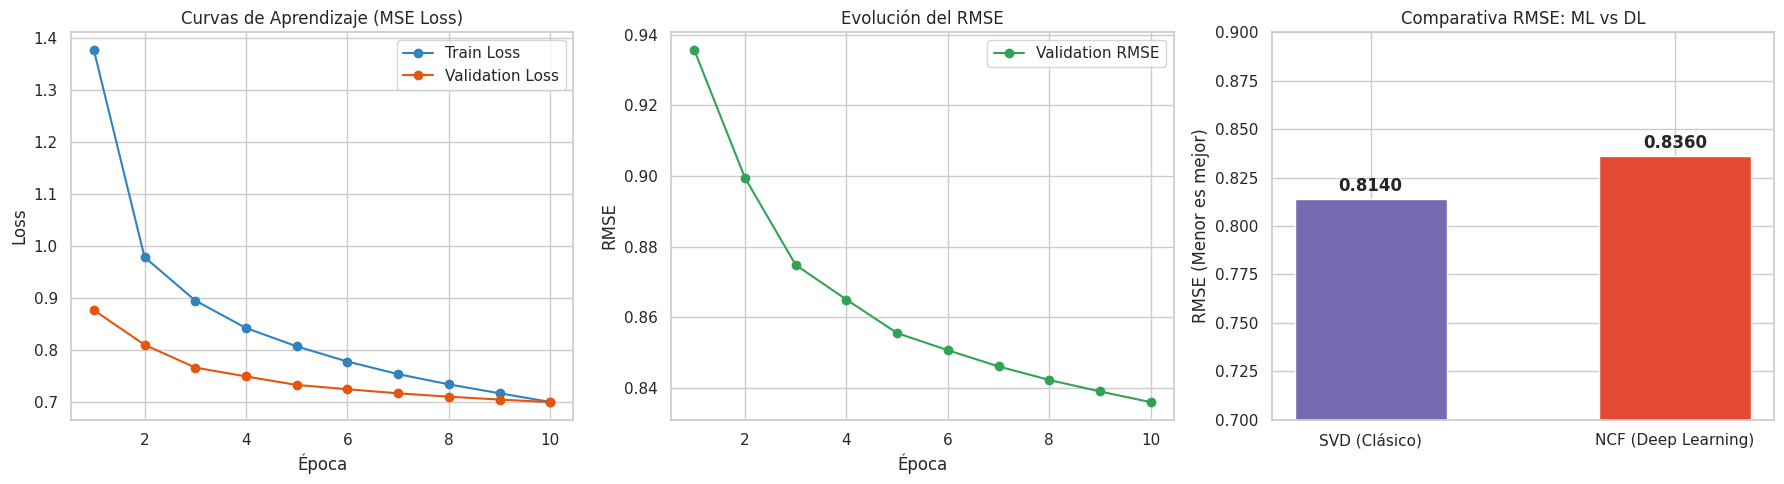

In [12]:
# ==========================================
# 6. EVALUACIÓN Y GRÁFICOS
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de Pérdida (Loss)
axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o', color='#3182bd')
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='#e6550d')
axes[0].set_title('Curvas de Aprendizaje (MSE Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Curva de RMSE
axes[1].plot(range(1, EPOCHS+1), val_rmses, label='Validation RMSE', color='#31a354', marker='o')
axes[1].set_title('Evolución del RMSE')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('RMSE')
axes[1].legend()

# 3. Comparativa vs Baseline Clásico
best_ncf_rmse = min(val_rmses)
best_svd_rmse = 0.8140  # Extraído del informe de la Fase 2

labels = ['SVD (Clásico)', 'NCF (Deep Learning)']
rmse_values = [best_svd_rmse, best_ncf_rmse]
colors = ['#756bb1', '#e34a33']

bars = axes[2].bar(labels, rmse_values, color=colors, width=0.5)
axes[2].set_ylim(0.70, 0.90)
axes[2].set_title('Comparativa RMSE: ML vs DL')
axes[2].set_ylabel('RMSE (Menor es mejor)')

for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Las gráficas de evaluación nos muestran claramente la convergencia del modelo. Las curvas de Train Loss y Validation Loss descienden en paralelo, validando la eficacia de la regularización L2 y el Dropout. Sin embargo, al contrastar el RMSE final, el modelo clásico SVD (0.8140) mantiene una ligera superioridad sobre la red profunda NCF (0.8360). Este conjunto de datos altamente disperso y submuestreado demuestra que los métodos de factorización matricial lineal son extremadamente eficientes. El Deep Learning, por su parte, requiere un volumen masivo de datos (como el dataset completo de 25M de registros) para que su arquitectura no lineal pueda superar definitivamente a los algoritmos clásicos.

### 6. Conclusiones y siguiente paso (Transición MLOps)

| Hallazgo | Decisión para Fase 5 (MLOps e Integración) |
| :--- | :--- |
| **Data Starvation:** La red NCF sufre de sobreajuste temprano con la muestra del 5%. | Mantener el **SVD clásico** como modelo de inferencia operativo principal en Django para este volumen de datos. |
| **SVD domina en Sparsity:** El producto punto lineal demostró ser más eficiente para matrices casi vacías que el MLP profundo. | El Deep Learning requeriría entrenarse en la nube sobre los 25M de registros completos para justificar su coste. |
| **Embeddings Extraídos:** Los vectores latentes son correctos y operables. | Exportaremos estos Embeddings a **ChromaDB / Faiss** para habilitar la etapa de Recuperación Semántica (RAG). |

**Siguientes notebooks / scripts**
* `05_Semantic_Search_RAG.ipynb` — Construcción de la base de datos vectorial para solucionar el *cold-start* mediante contenido.
* `src/inferencia.py` — Integración MLOps y tracking de modelos.